In [39]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import xarray as xr
import os
import matplotlib as mpl
fs=10
mpl.rc('xtick', labelsize=fs)
mpl.rc('ytick', labelsize=fs)
mpl.rc('legend', fontsize=fs)
mpl.rc('axes', titlesize=fs)
mpl.rc('axes', labelsize=fs)
mpl.rc('figure', titlesize=fs)
mpl.rc('font', size=fs)
mpl.rc('font', family='sans-serif', weight='normal', style='normal')
from permetrics.regression import RegressionMetric

In [40]:
from salishsea_tools import evaltools as et

In [41]:
# N_1 = pd.read_csv('SHEM_eval/dfo-2023-2024-Nutrients.csv',skiprows=1,parse_dates=['UTC'])
# N_1['UTC'] = N_1['UTC'].dt.tz_localize(None)
# N_1['UTC'] = N_1['UTC'].astype('datetime64[ns]')

# N_1 = N_1[N_1['umol/L']>=0]
# N_1 = N_1[N_1['m']>=0].reset_index(drop=True)

# N_1 = N_1.rename(columns={"degrees_north": "Lat", "degrees_east": "Lon",'UTC':'dtUTC','m':'Z','umol/L':'Nitrate'})

In [42]:
# N_2 = pd.read_csv('SHEM_eval/KC_2023-2025.csv',index_col=False) #*71.39
# N_2['Sample_Date'] = N_2['Sample_Date'].astype('datetime64[ns]')

# N_2 = N_2[N_2['NO23_field']>=0]
# N_2 = N_2[N_2['Sample_Depth']>=0].reset_index(drop=True)
# N_2 = N_2.rename(columns={"Latitude": "Lat", "Longitude": "Lon",'Sample_Date':'dtUTC','Sample_Depth':'Z','NO23_field':'Nitrate'})[["Lat","Lon","dtUTC","Z","Nitrate"]]

# N_2 = N_2.drop_duplicates().reset_index(drop=True)

In [43]:
# N_3 = pd.read_excel('SHEM_eval/PSF_N_2015-2023.xlsx',header=[0],skiprows =[1])

# N_3['dtUTC'] = (pd.to_datetime(N_3['date'].astype(str) + ' ' + N_3['time'].astype(str))
#     .dt.tz_localize('America/Vancouver')
#     .dt.tz_convert('UTC')
#     .dt.tz_localize(None))
# N_3['no3'] = N_3['no3'].astype(float)
# N_3 = N_3[N_3['no3']>=0]
# N_3 = N_3[N_3['depth']>=0].reset_index(drop=True)
# N_3 = N_3.rename(columns={"latitude": "Lat", "longitude": "Lon",'depth':'Z','no3':'Nitrate'})[["Lat","Lon","dtUTC","Z","Nitrate"]]

In [44]:
# data_N = pd.concat([N_1,N_2,N_3])

In [45]:
# filemap={'nitrate':'biol_T'}

# fdict={'biol_T':1}
# path = f'/data/jvalenti/results2/results2'
# mask_path = '/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc'

# start_date = dt.datetime(2023,1,1) 
# end_date = dt.datetime(2023,12,31) 

In [46]:
# data=et.matchData(data_N,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='SHEM')
# data.to_csv('N_23_SHEM.csv')

In [47]:
def calculate_rmse_bias(obs, predicted):
    """
    Calculates the Root Mean Squared Error (RMSE) between obs and predicted values.
    """
    # Calculate the squared differences
    differences_squared = (obs - predicted) ** 2
    # Calculate the mean of the squared differences (MSE)
    mean_of_differences_squared = differences_squared.mean()
    # Take the square root (RMSE)
    rmse_val = np.sqrt(mean_of_differences_squared)
    bias = (predicted - obs).mean()
    evaluator = RegressionMetric(np.array(obs), np.array(predicted))
    WI = evaluator.willmott_index()
    cor = np.corrcoef(obs, predicted)[0, 1]
    print(f"RMSE: {rmse_val}, Bias: {bias}, Willmott Index: {WI}, N: {len(obs)},Nmod: {len(predicted)}, Correlation: {cor}")
    return rmse_val, bias,WI,len(obs)

In [48]:
data = pd.read_csv('N_23_SHEM.csv') 
latmax = 47.97417#N_2.Lat.max()
data.loc[data['Lat'] < latmax, 'Nitrate'] *= 71.39

In [49]:
i_min = 82 
i_max = 292
j_min = 255
j_max = 735

data_inside = data[(data["i"].between(i_min, i_max) & data["j"].between(j_min, j_max))]
data_outside = data[~(data["i"].between(i_min, i_max) & data["j"].between(j_min, j_max))]

In [50]:
def plot_var(ax,data,name = "SHEM",var='DO_field',reg = 'inside',logscale = False,scatter =False,valim=[-1,45],namevar = 'Nitrate',valmin=0,title=False):
    model = np.array(data[name])
    obs = np.array(data[var])
    depth = np.array(data['Z'])
    mask_N = (obs > valmin) & (~np.isnan(model))
    rmse, bias, WI,N = calculate_rmse_bias(obs[mask_N], model[mask_N])

    if reg == "inside":
        cmapa, ctext, haa, vaa, xx, yy = 'Reds', 'red', 'left', 'top', 0.02, 0.98
    else:
        cmapa, ctext, haa, vaa, xx, yy = 'Greys','k', 'right', 'bottom', 0.98,0.02

    if scatter:
        ax.scatter(obs[mask_N],model[mask_N], alpha=0.6,color=ctext)
        ax.set_xlabel(f'{namevar}_observed')
    elif logscale:
        ax.hexbin(np.log10(obs[mask_N]+0.001), np.log10(model[mask_N]+0.001),gridsize=80, norm=mpl.colors.LogNorm(),cmap=cmapa,C=depth[mask_N])
        ax.set_xlabel(f'log({namevar}_observed)')
    else:
        ax.hexbin(obs[mask_N], model[mask_N],gridsize=80, norm=mpl.colors.LogNorm(),cmap=cmapa,C=depth[mask_N])
        ax.set_xlabel(f'{namevar}_observed')

    
    if title:
        ax.set_title(f'{name} vs Observed 2023 - 2025')
        
    ax.plot(np.linspace(valim[0], valim[1]),np.linspace(valim[0],valim[1]),'r--')
    s = f"{N:.0e}"
    s = s.replace("e+0", "e").replace("e+", "e").replace("e-0", "e-")
    ax.text(xx, yy,f'RMSE: {rmse:.2f}\nBias: {bias:.2f}\nWSS: {WI:.3f}',transform=ax.transAxes,ha=haa,va=vaa,color=ctext)

    ax.set_xlim(valim[0],valim[1])
    ax.set_ylim(valim[0],valim[1])

RMSE: 6.90703947988135, Bias: -6.233965779686298, Willmott Index: 0.6711927328257281, N: 104869,Nmod: 104869, Correlation: 0.8193106582247603
RMSE: 5.042645916169675, Bias: -1.6160347750556157, Willmott Index: 0.9109673579803413, N: 1323,Nmod: 1323, Correlation: 0.8479376164868477


Text(0, 0.5, 'Nitrate model [mmol/m3]')

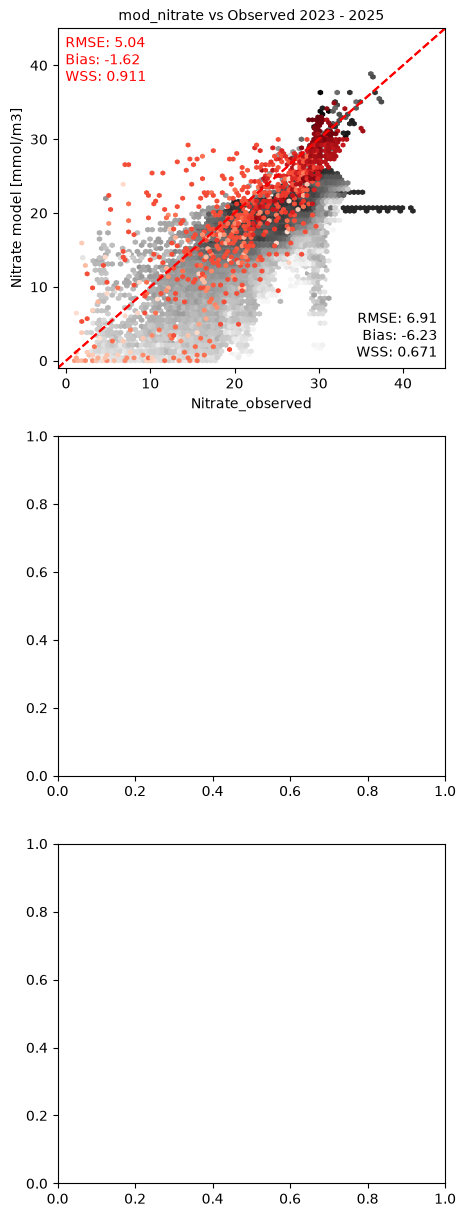

In [51]:
fig, axs = plt.subplots(3,1,figsize=(5,15))

plot_var(axs[0],data_outside,'mod_nitrate',reg='outside',var ='Nitrate',valmin=1,title=True)
plot_var(axs[0],data_inside,'mod_nitrate',var ='Nitrate',valmin=1,title=True)

axs[0].set_ylabel('Nitrate model [mmol/m3]')

In [52]:
data= pd.read_csv('DO_puget_2023_all.csv')
data2 = pd.read_csv('DO_2023_all.csv')

data_tot_23 = data[["dtUTC", "Z","DO_field","Lat","Lon","SHEM","j","i","v202111","v202410"]]
data_tot_23['DO_field'] = data_tot_23['DO_field']*31.25

data2_tot = data2.rename(columns={'DOXYZZ01':'DO_field'})
data2_tot['DO_field'] = data2_tot['DO_field']*44.66
data2_tot = data2_tot[["dtUTC", "Z","DO_field","Lat","Lon","SHEM","j","i","v202111","v202410"]]

data_tot_23 = pd.concat([data_tot_23,data2_tot])

/tmp/ipykernel_325718/243688782.py:1: DtypeWarning: Columns (0: DO_Qual, 1: NO23_Qual) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv('DO_puget_2023_all.csv')


In [53]:
data_tot_23 = data_tot_23[['Z','dtUTC','DO_field','Lon','Lat']]

data_tot_23['dtUTC'] = data_tot_23['dtUTC'].astype('datetime64[ns]')
data_tot_23['DO_field'] = data_tot_23['DO_field'].astype(float)
data_tot_23 = data_tot_23[data_tot_23['DO_field']>=0]
data_tot_23 = data_tot_23[data_tot_23['Z']>=0].reset_index(drop=True)

In [54]:
# filemap={'dissolved_oxygen':'biol_T'}

# data_tot=et.matchData(data_tot_23,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='SHEM')
# data_tot.to_csv('DO_23_SHEM.csv')

In [55]:
data_tot = pd.read_csv('DO_23_SHEM.csv')
i_min = 82 
i_max = 292
j_min = 255
j_max = 735

data_inside = data_tot[(data_tot["i"].between(i_min, i_max) & data_tot["j"].between(j_min, j_max))]
data_outside = data_tot[~(data_tot["i"].between(i_min, i_max) & data_tot["j"].between(j_min, j_max))]

RMSE: 25.122724569167254, Bias: -8.036241189974037, Willmott Index: 0.9493877152656595, N: 150005,Nmod: 150005, Correlation: 0.9163866744519013
RMSE: 30.983695395226697, Bias: -10.110791886860632, Willmott Index: 0.9062285704457665, N: 99099,Nmod: 99099, Correlation: 0.8464553669482152


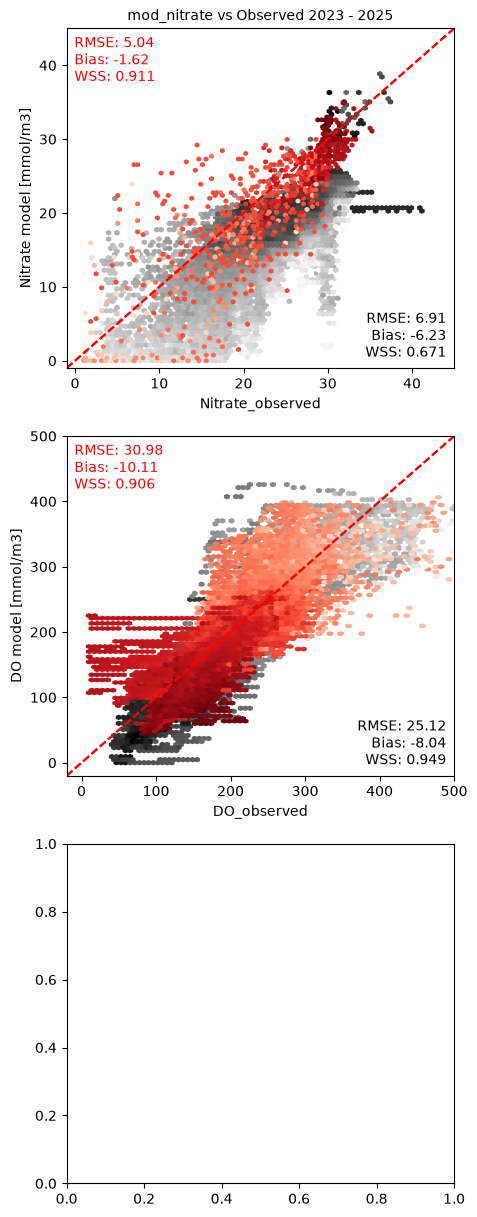

In [56]:
#fig,axs = plt.subplots(1,3,figsize=(15,5),sharey=True)

plot_var(axs[1],data_outside,'mod_dissolved_oxygen',reg='outside',var='DO_field',valim=[-20,500],namevar="DO",valmin=10)
plot_var(axs[1],data_inside,'mod_dissolved_oxygen',var='DO_field',valim=[-20,500],namevar="DO",valmin=10)

axs[1].set_ylabel('DO model [mmol/m3]')

fig

In [57]:
# chl_1 = pd.read_csv('SHEM_eval/dfo_chl.csv',header=[0],skiprows=[1],parse_dates=['time']) #mg/m^3
# chl_1['time'] = chl_1['time'].dt.tz_localize(None)
# chl_1['time'] = chl_1['time'].astype('datetime64[ns]')

# chl_1 = chl_1[chl_1['CPHLFLP1']>=0]
# chl_1 = chl_1[chl_1['depth']>=0].reset_index(drop=True)

# chl_1 = chl_1.rename(columns={"latitude": "Lat", "longitude": "Lon",'time':'dtUTC','depth':'Z','CPHLFLP1':'Chl'})[["Lat","Lon","dtUTC","Z","Chl"]]

In [58]:
# chl_2 = pd.read_csv('SHEM_eval/KC_2023-2025.csv',index_col=False) 
# chl_2['Sample_Date'] = chl_2['Sample_Date'].astype('datetime64[ns]')

# chl_2 = chl_2[chl_2['Chla_field']>=0]
# chl_2 = chl_2[chl_2['Sample_Depth']>=0].reset_index(drop=True)
# chl_2 = chl_2.rename(columns={"Latitude": "Lat", "Longitude": "Lon",'Sample_Date':'dtUTC','Sample_Depth':'Z','Chla_field':'Chl'})[["Lat","Lon","dtUTC","Z","Chl"]]

# chl_2 = chl_2.drop_duplicates().reset_index(drop=True)

In [59]:
# chl_3 = pd.read_csv('SHEM_eval/PSF_CTD_2025-2026.csv',header = [6],skiprows=[7],parse_dates=['datetime'])
# chl_3['datetime'] = chl_3['datetime'].astype('datetime64[ns]')

# chl_3['chl'] = chl_3['chl'].astype(float)
# chl_3 = chl_3[chl_3['chl']>=0]
# chl_3 = chl_3[chl_3['depth']>=0].reset_index(drop=True)
# chl_3 = chl_3.rename(columns={"latitude": "Lat", "longitude": "Lon",'depth':'Z','chl':'Chl','datetime':'dtUTC'})[["Lat","Lon","dtUTC","Z","Chl"]]

In [60]:
# data_chl = pd.concat([chl_1,chl_2,chl_3]).reset_index(drop=True)

In [61]:
# filemap={'diatoms':'biol_T','flagellates':'biol_T'}

# fdict={'biol_T':1}
# path = f'/data/jvalenti/results2/results2'
# mask_path = '/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc'

# start_date = dt.datetime(2023,1,1) 
# end_date = dt.datetime(2023,12,31) 

In [62]:
# data=et.matchData(data_chl,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='SHEM')
# data.to_csv('chl_23_SHEM.csv')

# # path = '/results2/SalishSea/nowcast-green.202111'
# # fdict={'biol_T':1}

# # data=et.matchData(data_chl,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# # data.to_csv('chl_23-25_202111.csv')

# # path = '/ocean/atall/MOAD/Model/202410b/oxygen/'
# # fdict={'biol_T':24}

# # data=et.matchData(data_chl,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# # data.to_csv('chl_23-25_202410.csv')

In [63]:
# # #Combine all versions in single file
data= pd.read_csv('chl_23_SHEM.csv')
data = data.rename(columns={'mod_diatoms':'SHEM_diatoms','mod_flagellates':'SHEM_flagellates'})
data['SHEM']=(data['SHEM_flagellates']+data['SHEM_diatoms'])*1.6

data = data[~np.isnan(data['SHEM'])&(data['Chl']>0)]
# data['v202111_diatoms']=data2['mod_diatoms']
# data['v202111_flagellates']=data2['mod_flagellates']
# data['v202111']=(data['v202111_flagellates']+data['v202111_diatoms'])*1.6

# data['v202410_diatoms']=data3['mod_diatoms']
# data['v202410_flagellates']=data3['mod_flagellates']
# data['v202410']=(data['v202410_flagellates']+data['v202410_diatoms'])*1.6

# data.to_csv('chl_whole_all.csv')

In [64]:
i_min = 82 
i_max = 292
j_min = 255
j_max = 735

data_inside = data[(data["i"].between(i_min, i_max) & data["j"].between(j_min, j_max))]
data_outside = data[~(data["i"].between(i_min, i_max) & data["j"].between(j_min, j_max))]

In [65]:
#fig,axs = plt.subplots(1,3,figsize=(15,5),sharey=True)

plot_var(axs[2],data_outside,'SHEM',reg='outside',var = 'Chl',valim=[-3,2],namevar='Chl',logscale=True)
#plot_var(axs[2],data_inside,'SHEM',var = 'Chl',valim=[-3,2],namevar='Chl',logscale=True)

axs[2].set_ylabel('log(Chl model) [mg/m3]')

RMSE: 1.4392184434960391, Bias: -0.3505353163601267, Willmott Index: 0.6827007643701308, N: 117539,Nmod: 117539, Correlation: 0.6430755144545325


Text(29.33658854166668, 0.5, 'log(Chl model) [mg/m3]')

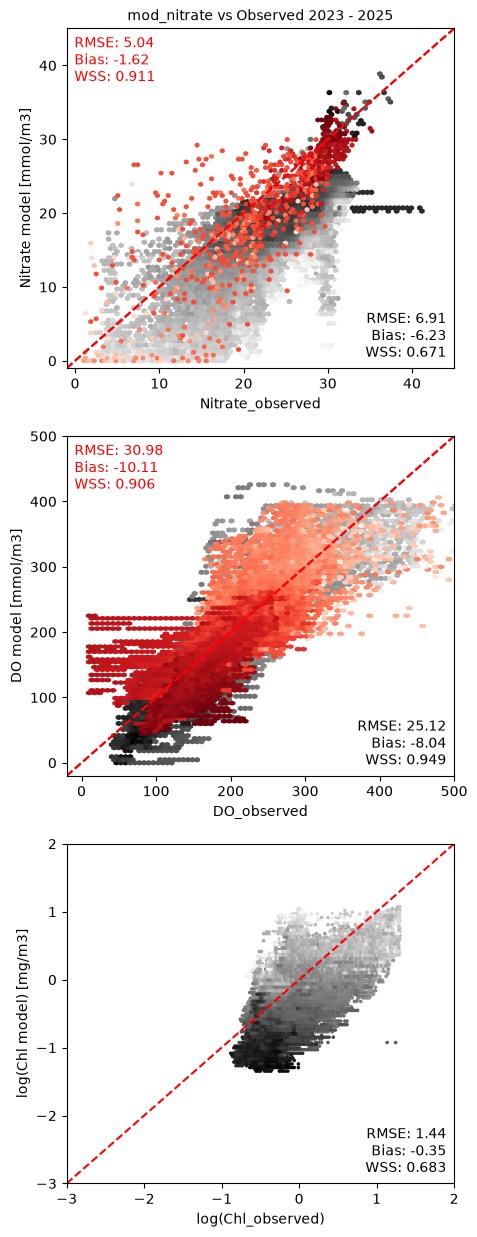

In [66]:
fig